In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("greenwing1985/housepricing")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/housepricing


In [ ]:
# prompt: ler em dataframe os dados

import pandas as pd

df = pd.read_csv(path + '/HousePrices_HalfMil.csv')

print(df.head())

   Area  Garage  FirePlace  Baths  White Marble  Black Marble  Indian Marble  \
0   164       2          0      2             0             1              0   
1    84       2          0      4             0             0              1   
2   190       2          4      4             1             0              0   
3    75       2          4      4             0             0              1   
4   148       1          4      2             1             0              0   

   Floors  City  Solar  Electric  Fiber  Glass Doors  Swiming Pool  Garden  \
0       0     3      1         1      1            1             0       0   
1       1     2      0         0      0            1             1       1   
2       0     2      0         0      1            0             0       0   
3       1     1      1         1      1            1             1       1   
4       1     2      1         0      0            1             1       1   

   Prices  
0   43800  
1   37550  
2   49500  
3 

In [ ]:
df.head()

,Area,Garage,FirePlace,Baths,White Marble,Black Marble,Indian Marble,Floors,City,Solar,Electric,Fiber,Glass Doors,Swiming Pool,Garden,Prices
0,164,2,0,2,0,1,0,0,3,1,1,1,1,0,0,43800
1,84,2,0,4,0,0,1,1,2,0,0,0,1,1,1,37550
2,190,2,4,4,1,0,0,0,2,0,0,1,0,0,0,49500
3,75,2,4,4,0,0,1,1,1,1,1,1,1,1,1,50075
4,148,1,4,2,1,0,0,1,2,1,0,0,1,1,1,52400


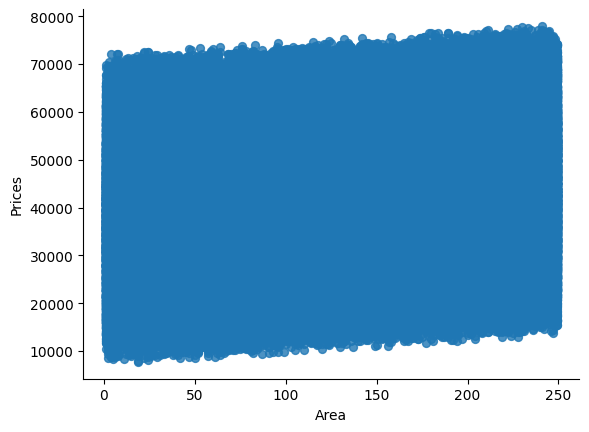

In [ ]:
# @title Área x Preço

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Area', y='Prices', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)


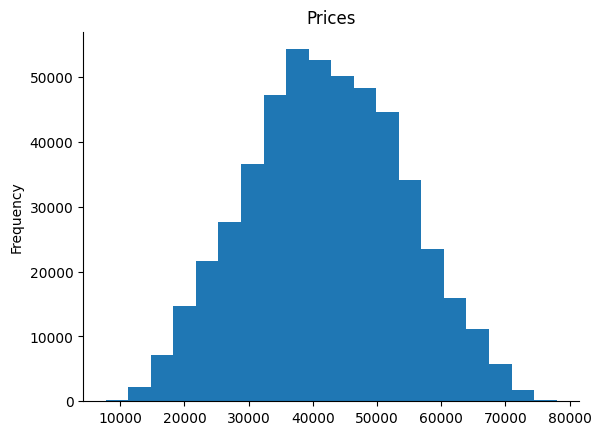

In [ ]:
# @title Preços

from matplotlib import pyplot as plt
df['Prices'].plot(kind='hist', bins=20, title='Prices')
plt.gca().spines[['top', 'right',]].set_visible(False)

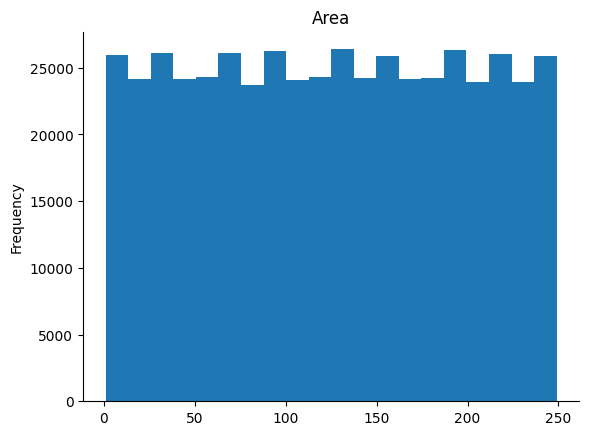

In [ ]:
# @title Área

from matplotlib import pyplot as plt
df['Area'].plot(kind='hist', bins=20, title='Area')
plt.gca().spines[['top', 'right',]].set_visible(False)

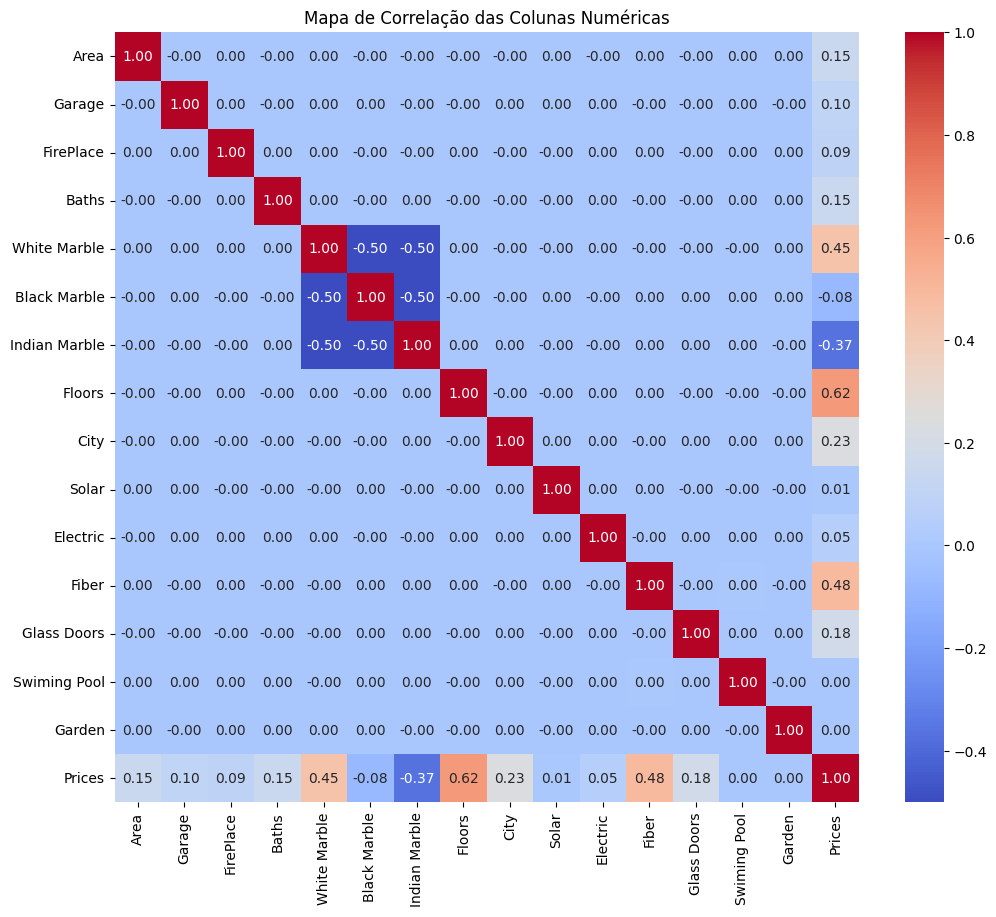

In [ ]:
# prompt: Usando o DataFrame df: gerar mapa de correlação entre consumo de cerveja

# Não há colunas relacionadas ao consumo de cerveja no DataFrame fornecido.
# O código abaixo geraria um mapa de calor de correlação para as colunas numéricas
# presentes no DataFrame 'df', que são dados de preços de casas.

import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas colunas numéricas
df_numeric = df.select_dtypes(include=['number'])

# Calcular a matriz de correlação
corr_matrix = df_numeric.corr()

# Gerar o mapa de calor (heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlação das Colunas Numéricas')
plt.show()

In [ ]:
# prompt: gerar modelo de regressão linear  para preços

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming 'df' is your DataFrame with preprocessed data
# (as in the previous code example)

# Define features (X) and target variable (y)
X = df[['Area', 'Garage', 'FirePlace', 'Baths', 'White Marble', 'Black Marble', 'Indian Marble', 'Floors', 'City', 'Solar', 'Eletric', 'Fíber', 'Glass Doors', 'Swiming Pool', 'Garden']]
y = df['Prices']


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Print model coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

KeyError: "['Eletric', 'Fíber'] not in index"